# QAOA Optimizer Test

We test the QAOA optimizer convergence, effect of depth p, and noise.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error

from Problem.IsingProblem import IsingProblem
from Algorithm.Classical_Algorithm.Exhaustive_search import exhaustive_search
from quantum_solver.qaoa_solver.qaoa_optimizer import QAOALocalOptimizer

## Create test instance (5 qubits)

In [2]:
# Random Ising instance with 5 variables
np.random.seed(42)
G = nx.Graph()
for i in range(5):
    G.add_node(i, weight=np.random.uniform(-1, 1))
for i in range(5):
    for j in range(i+1, 5):
        G.add_edge(i, j, weight=np.random.uniform(-1, 1))
ising = IsingProblem(G)

best_sol, best_cost = exhaustive_search(ising, maximize=False)
print(f"Optimal cost : {best_cost:.4f}")
print(f"Optimal solution : {best_sol}")

Optimal cost : -5.2182
Optimal solution : {'s_0': 1, 's_1': -1, 's_2': 1, 's_3': -1, 's_4': 1}


## QAOA for depth p = 1 to 6

In [3]:
depths = [1, 2, 3, 4, 5, 6]
n_runs = 5  # runs per depth for statistics
results_by_depth = {}

for p in depths:
    exp_vals = []
    for run in range(n_runs):
        optimizer = QAOALocalOptimizer(p=p, shots=2048, opt_method='COBYLA')
        exp_val, best_found, angles = optimizer.optimize(ising, p=p)
        exp_vals.append(exp_val)
    results_by_depth[p] = exp_vals
    print(f"p={p} : mean={np.mean(exp_vals):.4f}, std={np.std(exp_vals):.4f}, best={min(exp_vals):.4f}")

p=1 : mean=-0.3437, std=0.3733, best=-0.9626


p=2 : mean=-1.1552, std=0.4255, best=-1.8829


p=3 : mean=-1.2838, std=0.3025, best=-1.7810


p=4 : mean=-1.4650, std=0.5213, best=-2.4860


p=5 : mean=-1.0712, std=0.3698, best=-1.7349


p=6 : mean=-1.2439, std=0.2563, best=-1.5376


C:\Users\Thomas\AppData\Local\Temp\ipykernel_27944\2300111942.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([results_by_depth[p] for p in depths], labels=[str(p) for p in depths])


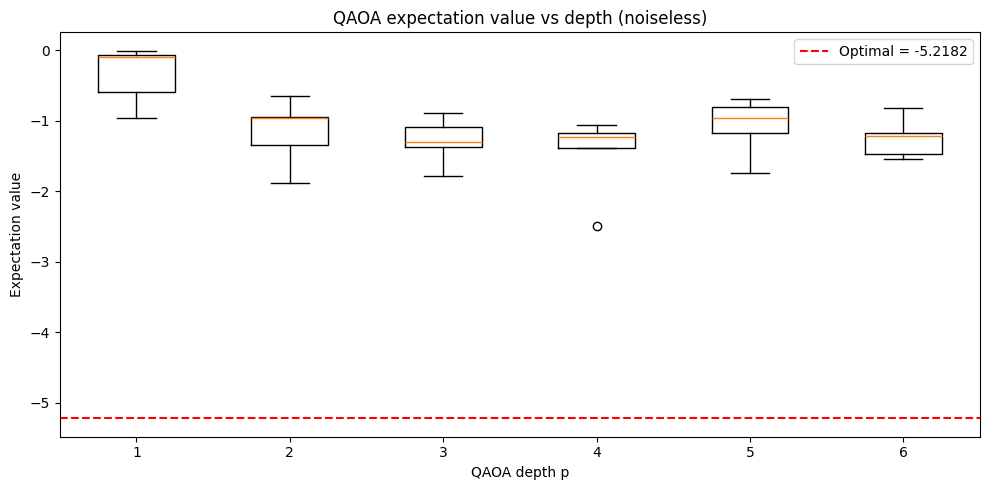

In [4]:
# Box plot of results
plt.figure(figsize=(10, 5))
plt.boxplot([results_by_depth[p] for p in depths], labels=[str(p) for p in depths])
plt.axhline(y=best_cost, color='r', linestyle='--', label=f'Optimal = {best_cost:.4f}')
plt.xlabel('QAOA depth p')
plt.ylabel('Expectation value')
plt.title('QAOA expectation value vs depth (noiseless)')
plt.legend()
plt.tight_layout()
plt.show()

## Compare different scipy optimization methods

In [5]:
methods = ['COBYLA', 'Nelder-Mead', 'Powell']
results_by_method = {}

for method in methods:
    exp_vals = []
    for run in range(5):
        optimizer = QAOALocalOptimizer(p=2, shots=2048, opt_method=method)
        exp_val, _, _ = optimizer.optimize(ising)
        exp_vals.append(exp_val)
    results_by_method[method] = exp_vals
    print(f"{method} : mean={np.mean(exp_vals):.4f}, std={np.std(exp_vals):.4f}")

COBYLA : mean=-1.0926, std=0.2969


Nelder-Mead : mean=-1.0032, std=0.3276


Powell : mean=-1.2888, std=0.5704


C:\Users\Thomas\AppData\Local\Temp\ipykernel_27944\3257155523.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([results_by_method[m] for m in methods], labels=methods)


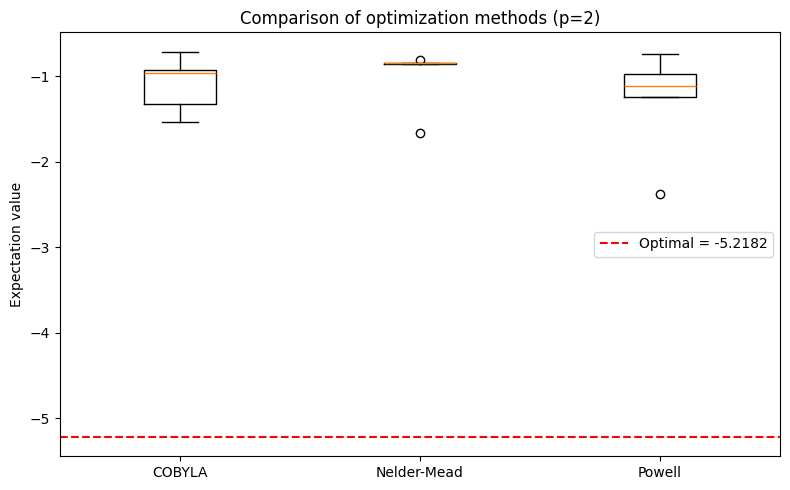

In [6]:
plt.figure(figsize=(8, 5))
plt.boxplot([results_by_method[m] for m in methods], labels=methods)
plt.axhline(y=best_cost, color='r', linestyle='--', label=f'Optimal = {best_cost:.4f}')
plt.ylabel('Expectation value')
plt.title('Comparison of optimization methods (p=2)')
plt.legend()
plt.tight_layout()
plt.show()

COBYLA tends to work well for QAOA because it is a gradient-free method that handles the noisy objective function well. It doesn't need gradient information which is hard to get from a quantum circuit. Nelder-Mead also works but can be slower to converge.

## Noisy simulation

We add a simple depolarizing noise model to see how it impacts the optimization.

In [7]:
# Create a noisy simulator with depolarizing error
noise_model = NoiseModel()
# Add depolarizing error to single and two qubit gates
error_1q = depolarizing_error(0.01, 1)  # 1% error on single qubit gates
error_2q = depolarizing_error(0.02, 2)  # 2% error on two qubit gates
noise_model.add_all_qubit_quantum_error(error_1q, ['rx', 'rz', 'h'])
noise_model.add_all_qubit_quantum_error(error_2q, ['cx'])

noisy_sim = AerSimulator(noise_model=noise_model)
print("Noisy simulator created.")

Noisy simulator created.


In [8]:
# Compare noiseless vs noisy for different depths
results_noisy = {}
results_clean = {}

for p in [1, 2, 3, 4]:
    noisy_vals = []
    clean_vals = []
    for run in range(5):
        # Noiseless
        opt_clean = QAOALocalOptimizer(p=p, shots=2048, opt_method='COBYLA')
        ev_clean, _, _ = opt_clean.optimize(ising)
        clean_vals.append(ev_clean)
        # Noisy
        opt_noisy = QAOALocalOptimizer(simulator=noisy_sim, p=p, shots=2048, opt_method='COBYLA')
        ev_noisy, _, _ = opt_noisy.optimize(ising)
        noisy_vals.append(ev_noisy)
    results_clean[p] = clean_vals
    results_noisy[p] = noisy_vals
    print(f"p={p} : clean={np.mean(clean_vals):.4f}, noisy={np.mean(noisy_vals):.4f}")

p=1 : clean=-1.3647, noisy=-0.7978


p=2 : clean=-1.0859, noisy=-0.9241


p=3 : clean=-1.5773, noisy=-0.3333


p=4 : clean=-1.2545, noisy=-0.2225


C:\Users\Thomas\AppData\Local\Temp\ipykernel_27944\3917428554.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([results_clean[p] for p in depths_test], labels=[str(p) for p in depths_test])
C:\Users\Thomas\AppData\Local\Temp\ipykernel_27944\3917428554.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([results_noisy[p] for p in depths_test], labels=[str(p) for p in depths_test])


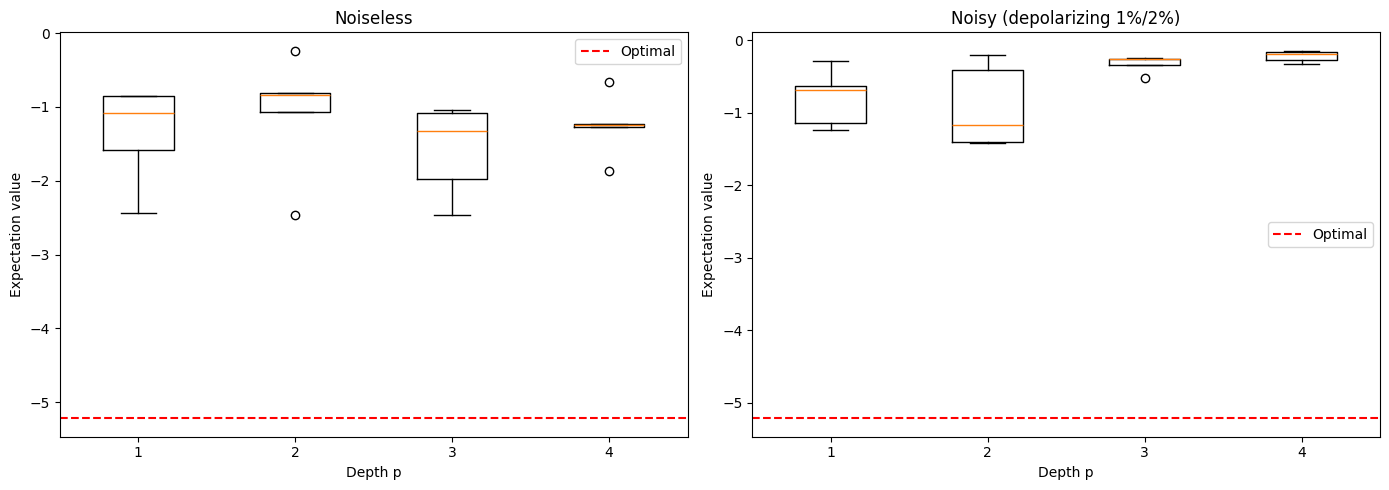

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

depths_test = [1, 2, 3, 4]
axes[0].boxplot([results_clean[p] for p in depths_test], labels=[str(p) for p in depths_test])
axes[0].axhline(y=best_cost, color='r', linestyle='--', label=f'Optimal')
axes[0].set_title('Noiseless')
axes[0].set_xlabel('Depth p')
axes[0].set_ylabel('Expectation value')
axes[0].legend()

axes[1].boxplot([results_noisy[p] for p in depths_test], labels=[str(p) for p in depths_test])
axes[1].axhline(y=best_cost, color='r', linestyle='--', label=f'Optimal')
axes[1].set_title('Noisy (depolarizing 1%/2%)')
axes[1].set_xlabel('Depth p')
axes[1].set_ylabel('Expectation value')
axes[1].legend()

plt.tight_layout()
plt.show()

## Observations

- As the depth p increases, the noiseless QAOA tends to reach better (lower) expectation values because it has more parameters to optimize.
- With noise, increasing p does not necessarily help because deeper circuits accumulate more errors. There is a tradeoff between circuit expressiveness and noise.
- The noisy simulation generally gives worse expectation values than the noiseless one, especially for higher depths where more gates are applied.
- This is consistent with the NISQ (Noisy Intermediate-Scale Quantum) paradigm: shallow circuits are more practical on current hardware.